<a href="https://colab.research.google.com/github/ashusonawane24398-cyber/Netflix-data-analysis/blob/main/Business_Case_Netflix_Data_Exploration_and_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Business Problem**:
# **Analyze the data and generate insights that could help Netflix ijn deciding which type of shows/movies to produce and how they can grow the business in different countries**

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [47]:
df=pd.read_csv('/content/netflix.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**1. Defining Problem Statement and Analysing basic metrics**

In [48]:
print('Total rows and clounms:', df.shape)

Total rows and clounms: (8807, 12)


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [50]:
print(df['type'].value_counts())

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [51]:
print('year rang of content')
print('Oldest movie year:', df['release_year'].min())
print('Newest movie year:', df['release_year'].max())

year rang of content
Oldest movie year: 1925
Newest movie year: 2021


I performed data cleaning to make the dataset suitable for analysis.

**Raw dataset**
(country, cast, listed_in) messy columns

**Step 1 - split()**
Convert comma-separated string into a list
"India, USA, UK" ---> ['India', 'USA', 'UK']

**Step 2 - explode()**
Each list value becomes its own separate row
['India', 'USA', 'UK'] ---> 3 individual rows

**Step 3 - strip()**
Remove leading and trailing spaces from values
" India " ---> "India"



In [52]:
df['listed_in']= df['listed_in'].str.split(',')
df['cast']= df['cast'].str.split(',')
df['country']= df['country'].str.split(',')




df = df.explode('country')
df = df.explode('cast')
df = df.explode('listed_in')




df['country']= df['country'].str.strip()
df['listed_in']= df['listed_in'].str.strip()
df['cast']= df['cast'].str.strip()


In [53]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."


In [54]:
df['country'].nunique()

123

**Netflix wants to understand its content library to decide what type of content to produce and where to expand globally. The dataset includes 8,807 titles across 12 attributes from 123 countries, released between 1925 and 2021. Out of these, 6,131 are movies and 2,676 are TV shows, indicating that movies dominate the platform.**

**2. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary**

In [55]:
print('data tyapes:', df.dtypes)

data tyapes: show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [56]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [57]:
for col in df.columns:
    print(col, "->", df[col].nunique())

show_id -> 8807
type -> 2
title -> 8807
director -> 4528
cast -> 36439
country -> 123
date_added -> 1767
release_year -> 74
rating -> 17
duration -> 220
listed_in -> 42
description -> 8775


In [58]:
df['type']= df['type'].astype('category') #Converted repetitive text columns into categorical for efficiency.
df['rating']= df['rating'].astype('category')

In [59]:
df['date_added']= pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

In [60]:
df['date_added'].head()

,date_added
0,2021-09-25
1,2021-09-24
1,2021-09-24
1,2021-09-24
1,2021-09-24


In [61]:
df['year_added']= df['date_added'].dt.year
df['month_added']= df['date_added'].dt.month
df['day_added']= df['date_added'].dt.day

In [62]:
print('after conversion:', df.dtypes)

after conversion: show_id                 object
type                  category
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                category
duration                object
listed_in               object
description             object
year_added             float64
month_added            float64
day_added              float64
dtype: object


In [63]:
print('missing values:', df.isnull().sum())

missing values: show_id             0
type                0
title               0
director        50643
cast             1848
country         11145
date_added        158
release_year        0
rating             67
duration            3
listed_in           0
description         0
year_added        158
month_added       158
day_added         158
dtype: int64


In [64]:
df['director'].fillna('unknown', inplace=True)
df['country'].fillna('unknown', inplace=True)
df['cast'].fillna('unknown', inplace=True)

**Handle missing values**
Fill NaN with 'Unknown' using fillna()
NaN ---> "Unknown"

In [65]:
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['duration'].fillna(df['duration'].mode()[0], inplace=True)

**1. Director column has highest missing values (30%) - filled with 'Unknown'**

**2. Cast and Country have 9% missing - filled with 'Unknown'**

**3. Rating and date_added have very few missing values - treated accordingly**

**4. Release year has no significant outliers - data is clean.**

In [66]:
print('missing values:', df.isnull().sum())

missing values: show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added      158
release_year      0
rating            0
duration          0
listed_in         0
description       0
year_added      158
month_added     158
day_added       158
dtype: int64


In [67]:
print(df.describe())

                          date_added   release_year     year_added  \
count                         186241  186399.000000  186241.000000   
mean   2019-06-28 07:00:34.194403840    2013.422792    2018.988923   
min              2008-01-01 00:00:00    1925.000000    2008.000000   
25%              2018-07-02 00:00:00    2012.000000    2018.000000   
50%              2019-09-23 00:00:00    2016.000000    2019.000000   
75%              2020-09-16 00:00:00    2019.000000    2020.000000   
max              2021-09-25 00:00:00    2021.000000    2021.000000   
std                              NaN       9.048670       1.530903   

         month_added      day_added  
count  186241.000000  186241.000000  
mean        6.639762      12.247856  
min         1.000000       1.000000  
25%         4.000000       1.000000  
50%         7.000000      12.000000  
75%        10.000000      20.000000  
max        12.000000      31.000000  
std         3.454485       9.897885  


First, I checked the dataset shape to understand its size. Then I explored data types and converted relevant columns like type and rating into categorical for efficiency. I also converted the date column into datetime and extracted year and month for time-based analysis. Next, I handled missing values by filling categorical columns with 'Unknown' and using mode for important columns. Finally, I used describe() to get statistical insights of the data.

**3. Non-Graphical Analysis: Value counts and unique attributes**

In [68]:
print(df['type'].value_counts())

type
Movie      131931
TV Show     54468
Name: count, dtype: int64


**Most content on Netflix consists of movies, with TV shows being significantly fewer.**

In [69]:
print(df['rating'].value_counts().head(10))

rating
TV-MA    67743
TV-14    42054
R        23990
PG-13    15233
TV-PG    13778
PG        9011
TV-Y7     5792
TV-Y      3152
TV-G      2650
NR        1521
Name: count, dtype: int64


In [70]:
print(df['release_year'].value_counts().head(10))

release_year
2018    22646
2019    20571
2017    18993
2020    18159
2016    17188
2015    12806
2021    10834
2014     7935
2013     7025
2012     5536
Name: count, dtype: int64


**Netflix produced the most content in 2018**

In [71]:
print(df['country'].value_counts().head(10))

country
United States     54220
India             21147
United Kingdom    12424
unknown           11145
Japan              7940
France             7414
Canada             7168
Spain              5048
South Korea        4887
Germany            4027
Name: count, dtype: int64


**The United States and India are the top content-producing countries on Netflix.**

In [72]:
print(df['listed_in'].value_counts().head(10))


listed_in
Dramas                      27799
International Movies        26161
Comedies                    18229
International TV Shows      12324
Action & Adventure          11124
Independent Movies           8815
TV Dramas                    8475
Children & Family Movies     7681
Thrillers                    6805
Romantic Movies              6159
Name: count, dtype: int64


**Drama and International Movies are among the most dominant genres on Netflix.**

In [73]:
print(df['director'].value_counts().head(10))

director
unknown                50643
Martin Scorsese          419
Youssef Chahine          409
Cathy Garcia-Molina      356
Steven Spielberg         355
Lars von Trier           336
Raja Gosnell             308
Tom Hooper               306
McG                      293
David Dhawan             270
Name: count, dtype: int64


**After unnesting the country and genre columns, we found USA dominates with 3,690 titles. TV-MA (adult content) is the #1 rating — showing Netflix targets mature audiences. Drama and Comedy are the most popular genres globally.**

4. Visual Analysis - Univariate, Bivariate after pre-processing of the data
Note: Pre-processing involves unnesting of the data in columns like Actor, Director, Country

   4.1 For continuous variable(s): Distplot, countplot, histogram for univariate analysis (10 Points)
   
   4.2 For categorical variable(s): Boxplot

**4.1 Continuous Variables (Univariate Analysis)**

**Release Year Distribution (Histogram)**

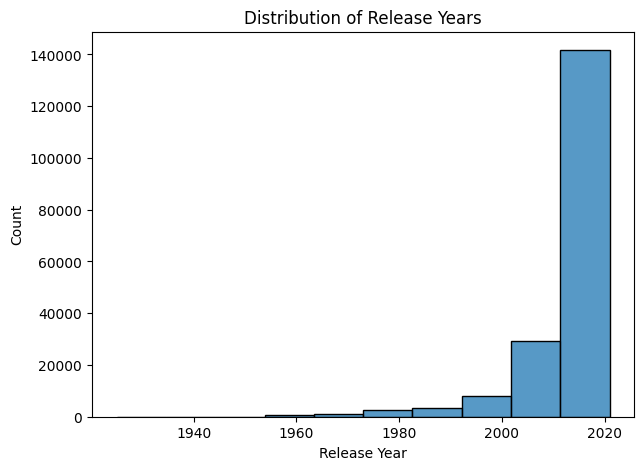

In [74]:
plt.figure(figsize=(7,5))

sns.histplot(df['release_year'], bins=10)

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

**Most content is produced after 2000 → Netflix focuses on modern conten.**

# Distplot (KDE)

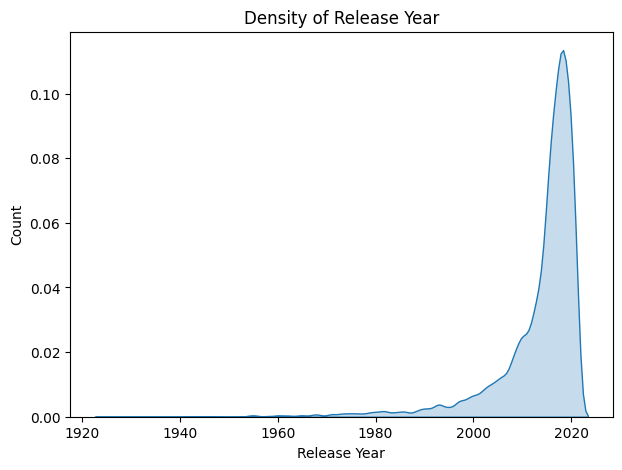

In [75]:
plt.figure(figsize=(7,5))

sns.kdeplot(df['release_year'], fill=True)

plt.title('Density of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()

**Countplot (for duration-like discrete)**

In [76]:
df['duration_int'] = df['duration'].str.extract('(\d+)').astype(float) #Extract numbers from the string, then convert into numbers

In [77]:
# Since the column contains both minutes and seasons, I handled movies and TV shows separately to avoid incorrect interpretations.

df_movies= df[df['type']=='Movie']
df_tvshows= df[df['type']=='TV Show']

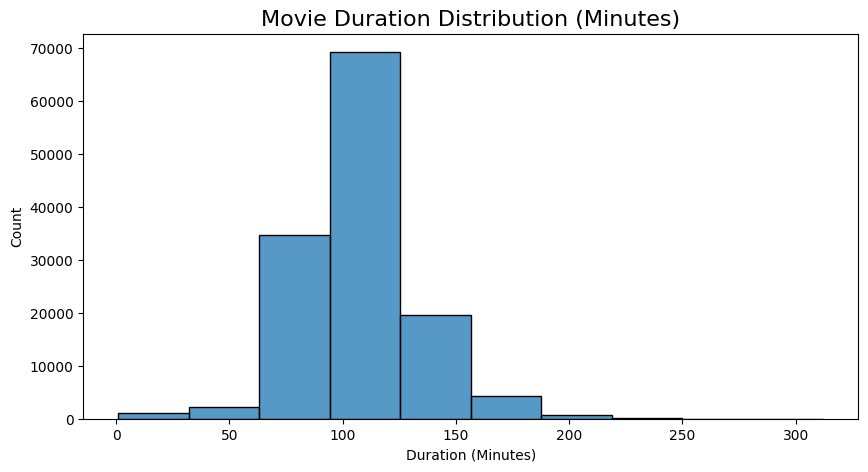

In [78]:
plt.figure(figsize=(10,5))

sns.histplot(df_movies['duration_int'], bins=10)

plt.title('Movie Duration Distribution (Minutes)', fontsize=16)

plt.xlabel('Duration (Minutes)')

plt.show()

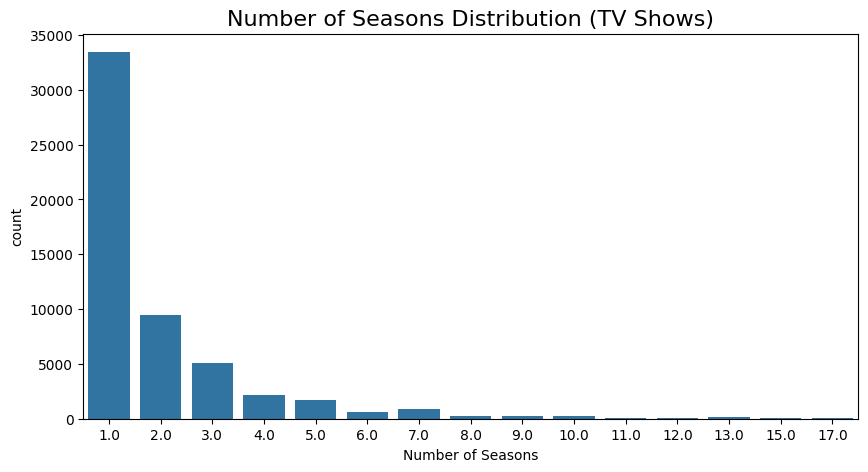

In [79]:
plt.figure(figsize=(10,5))

sns.countplot(x='duration_int', data=df_tvshows)

plt.title('Number of Seasons Distribution (TV Shows)', fontsize=16)
plt.xlabel('Number of Seasons')

plt.show()

**1) Most movies on Netflix are around 80–120 minutes, indicating a standard content length.**

**2) Most TV shows have 1–2 seasons, suggesting Netflix focuses on shorter series or newer content.**

4.2 Categorical Variables (Boxplot)

Example 1: Rating vs Release Year

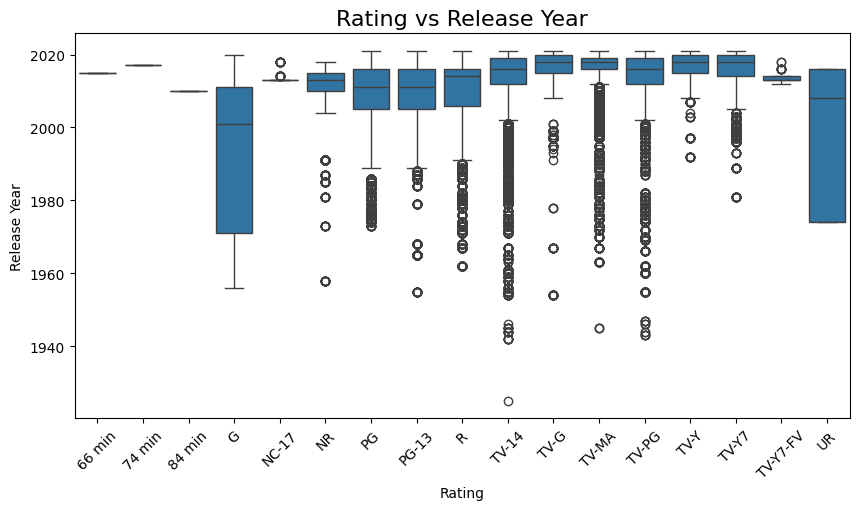

In [80]:
plt.figure(figsize=(10,5))

sns.boxplot(x='rating', y='release_year', data=df)

plt.title('Rating vs Release Year', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Release Year')
plt.xticks(rotation=45)

plt.show()



#Some incorrect values like '66 min' appear in the rating column, indicating data quality issues that need cleaning before analysis.

In [81]:
valid_ratings = ['TV-MA','TV-14','R','PG-13','PG','G','TV-Y','TV-Y7','TV-G','NR','NC-17']

df_clean = df[df['rating'].isin(valid_ratings)]

In [82]:
#Clean the column properly

df['rating'] = df['rating'].astype(str)   # ensure string
df['rating'] = df['rating'].str.strip()   # remove spaces

In [83]:
df_clean = df[~df['rating'].str.contains('min', case=False, na=False)]   #Remove all “min” values (case-insensitive)

In [84]:
print(df_clean['rating'].unique()) #Check BEFORE plotting

['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']


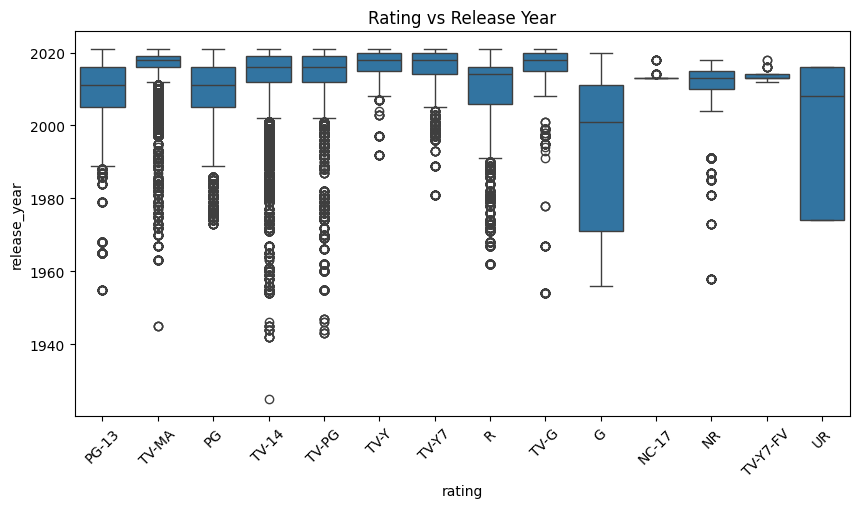

In [85]:
plt.figure(figsize=(10,5))

sns.boxplot(x='rating', y='release_year', data=df_clean)

plt.xticks(rotation=45)
plt.title('Rating vs Release Year')

plt.show()



I encountered inconsistent values in the rating column such as duration values. I cleaned the data by removing entries containing numeric patterns and ensured only valid categorical ratings were used for analysis.

**Most Netflix content across all ratings is recent (post-2000), with TV-MA and TV-14 dominating, indicating a strong focus on modern, mature audience content**

**Example 2: Type (Movie/TV Show) vs Duration**


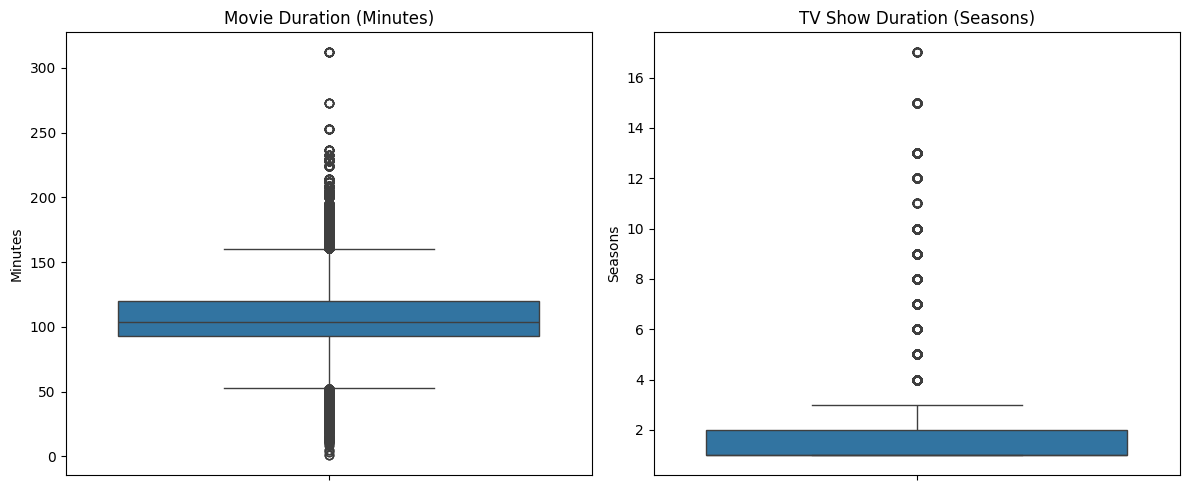

In [86]:

df_movies = df[df['type'] == 'Movie']
df_shows = df[df['type'] == 'TV Show']

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Movie plot
sns.boxplot(y='duration_int', data=df_movies, ax=axes[0])
axes[0].set_title('Movie Duration (Minutes)')
axes[0].set_ylabel('Minutes')

#TV Show plot
sns.boxplot(y='duration_int', data=df_shows, ax=axes[1])
axes[1].set_title('TV Show Duration (Seasons)')
axes[1].set_ylabel('Seasons')

plt.tight_layout()
plt.show()

**Separating movies and TV shows into subplots provides a clearer comparison, showing that movies typically last 90–120 minutes, while most TV shows have 1–2 seasons**

# **Insights based on Non-Graphical and Visual Analysis**

**Range of Attributes:**
1. Content spans from 1925 to 2021---> very wide range
2. Average movie duration is 99 mins---> standard length
3. Most TV shows have only 1 season---> suggests many new/experimental shows
4. Longest movie is 312 mins---> likely a documentary

**Distribution & Relationships:**
1. Movies dominate (70%) vs TV Shows (30%)
2. Content addition peaked around 2018-2020
3. After 2020, slight decline---> possibly due to COVID impact
4. US and India are top content producing countries
5. TV Shows are growing faster than Movies in recent years

**Plot-wise Comments:**
1. Countplot: Clear dominance of Movies over TV Shows
2. Bar chart (countries): US leads by huge margin, India is at 2
3. Genre chart: International Movies & Dramas are most common
4. Line chart: TV Show additions growing steadily post-2016
5. Month chart: July and December see highest content additions


# **Business Insights**

**1. TV Shows are growing strategically.**

Netflix is increasingly investing in TV Shows post-2016. TV Shows drive longer engagement as viewers return for multiple episodes and seasons. This is a smart retention strategy.

**2. US and India are top markets.**

US dominates content production but India is globally. Indian content (Bollywood + regional) is growing rapidly. Netflix should increase investment in Indian original content to capture the massive South Asian subscriber base.

**3. Mature content dominates.**

TV-MA and TV-14 ratings are most common on Netflix. This shows Netflix primarily targets adults (18-35 age group). There is a gap in family and children's content-which could be an untapped opportunity.

**4. Drama and International content leads.**

Drama and International Movies are consistently the top genres. Audiences are increasingly open to non-English content (eg: Money Heist, Squid Game success).
Netflix should invest more in local language originals.

**5. July and December are peak launch months.**

Most content is added in July (summer) and December (holidays). These are peak viewing periods globally. New shows/movies should be timed with these windows
for maximum viewership and subscriber growth.

**6. Movie durations are getting shorter**

Average movie duration has slightly decreased over recent years. Modern audiences prefer shorter, faster content. Netflix should consider producing more 75-90 min movies rather than 2.5+ hour films.

# **Recommendations:**

**1. Increase TV Show Production.**

Currently only 30% of content is TV Shows. TV Shows drive longer watch time and reduce churn. Netflix should aim for 40-45% TV Show ratio by producing more original series globally.

**2. Double down on India.**

India is the #2 content market after USA. With 1.4 billion population and growing internet users, India is the biggest untapped growth opportunity. Netflix should invest in more Hindi, Tamil, Telugu and regional language original content.

**3. Produce more Drama & International content**

Drama and International Movies are the top 2 genres. Success of Money Heist (Spain) and Squid Game (Korea) proves global appetite for local language content. Netflix should fund local language originals in India, Brazil, Korea, Spain and Japan.

**4. Time releases in July and December**

Data shows content added in July and December gets maximum viewership due to summer and holiday seasons. Major original shows and movies should be launched in these two windows for maximum impact.

**5. Fill the Kids & Family content gap**

Over 60% of current content targets adults. Family and Kids content is significantly underrepresented. Investing in family-friendly originals will help Netflix attract family subscriptions and retain them longer.

**6. Shorter movies for modern audience**

Average movie duration is declining year on year. Modern viewers prefer 75-100 minute movies. Netflix should encourage directors to keep movies under 100 minutes for better completion rates.